In [80]:
from env import env
from agent import Agent
import numpy as np
import matplotlib.pyplot as plt
import random

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Model-free



These are the AGENT'S POLICIES. The Probability matrix of the environment does not have anything to do with these.

In [81]:
chef = Agent()
print(chef.state.number)

chef.state = chef.action_left()
print(chef.state.number)

chef.state = chef.action_up()
print(chef.state.number)

9
8
16


In [82]:
gamma = 0.8
alpha = 0.2
first,second = chef.improve_policy(10000,gamma,alpha).items()

episodio 0 completato
episodio 1 completato
episodio 2 completato
episodio 3 completato
episodio 4 completato
episodio 5 completato
episodio 6 completato
episodio 7 completato
episodio 8 completato
episodio 9 completato
episodio 10 completato
episodio 11 completato
episodio 12 completato
episodio 13 completato
episodio 14 completato
episodio 15 completato
episodio 16 completato
episodio 17 completato
episodio 18 completato
episodio 19 completato
episodio 20 completato
episodio 21 completato
episodio 22 completato
episodio 23 completato
episodio 24 completato
episodio 25 completato
episodio 26 completato
episodio 27 completato
episodio 28 completato
episodio 29 completato
episodio 30 completato
episodio 31 completato
episodio 32 completato
episodio 33 completato
episodio 34 completato
episodio 35 completato
episodio 36 completato
episodio 37 completato
episodio 38 completato
episodio 39 completato
episodio 40 completato
episodio 41 completato
episodio 42 completato
episodio 43 completat

episodio 0 completato
episodio 1 completato
episodio 2 completato
episodio 3 completato
episodio 4 completato
episodio 5 completato
episodio 6 completato
episodio 7 completato
episodio 8 completato
episodio 9 completato
episodio 10 completato
episodio 11 completato
episodio 12 completato
episodio 13 completato
episodio 14 completato
episodio 15 completato
episodio 16 completato
episodio 17 completato
episodio 18 completato
episodio 19 completato
episodio 20 completato
episodio 21 completato
episodio 22 completato
episodio 23 completato
episodio 24 completato
episodio 25 completato
episodio 26 completato
episodio 27 completato
episodio 28 completato
episodio 29 completato
episodio 30 completato
episodio 31 completato
episodio 32 completato
episodio 33 completato
episodio 34 completato
episodio 35 completato
episodio 36 completato
episodio 37 completato
episodio 38 completato
episodio 39 completato
episodio 40 completato
episodio 41 completato
episodio 42 completato
episodio 43 completat

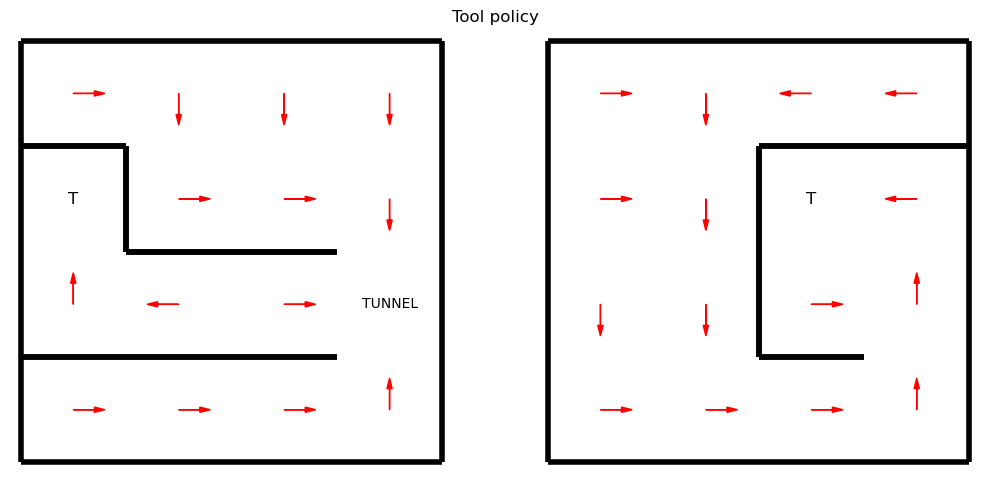

In [86]:
gamma = 0.8
alpha = 0.1

policies = chef.improve_policy(10000, gamma, alpha)
tool_policy = policies["tool"]
cook_policy = policies["cook"]

n_rows, n_cols = 4, 8

def col_to_x(col):
    """Aggiunge uno spazio visivo tra i due blocchi (dopo la colonna logica 3)."""
    return col if col < 4 else col + 1

fig, ax = plt.subplots(figsize=(10, 5))

def draw_arrow(ax, x, y, direction):
    if direction == 'up':
        ax.arrow(x, y, 0, 0.2, head_width=0.05, head_length=0.1, color='red')
    elif direction == 'down':
        ax.arrow(x, y, 0, -0.2, head_width=0.05, head_length=0.1, color='red')
    elif direction == 'left':
        ax.arrow(x, y, -0.2, 0, head_width=0.05, head_length=0.1, color='red')
    elif direction == 'right':
        ax.arrow(x, y, 0.2, 0, head_width=0.05, head_length=0.1, color='red')
    elif direction == 'take':
        ax.text(x, y, "T", fontsize=12, ha="center", va="center")
    elif direction == 'tunnel':
        ax.text(x, y, "TUNNEL", fontsize=10, ha="center", va="center")

def draw_wall(ax, row, col, side):
    x = col_to_x(col)
    x0, x1 = x - 0.5, x + 0.5
    y0, y1 = row - 0.5, row + 0.5
    if side == 'up':
        ax.plot([x0, x1], [y1, y1], color='black', linewidth=4, solid_capstyle='butt')
    elif side == 'down':
        ax.plot([x0, x1], [y0, y0], color='black', linewidth=4, solid_capstyle='butt')
    elif side == 'left':
        ax.plot([x0, x0], [y0, y1], color='black', linewidth=4, solid_capstyle='butt')
    elif side == 'right':
        ax.plot([x1, x1], [y0, y1], color='black', linewidth=4, solid_capstyle='butt')

# --- Frecce della policy ---
for state_number, move in enumerate(tool_policy):
    row = state_number // n_cols
    col = state_number % n_cols
    x = col_to_x(col)
    draw_arrow(ax, x, row, move)

# --- Muri ---
for state_number in range(n_rows * n_cols):
    row = state_number // n_cols
    col = state_number % n_cols

    if state_number in env.up_forbidden:
        draw_wall(ax, row, col, 'up')
    if state_number in env.down_forbidden:
        draw_wall(ax, row, col, 'down')
    if state_number in env.left_forbidden:
        draw_wall(ax, row, col, 'left')
    if state_number in env.right_forbidden:
        draw_wall(ax, row, col, 'right')

ax.set_xlim(-0.6, n_cols + 0.6)
ax.set_ylim(-0.6, n_rows - 0.4)
ax.set_aspect('equal')
ax.axis('off')
plt.title("Tool policy")
plt.tight_layout()
plt.show()